In [ ]:
import numpy as np
import joblib
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import f1_score, roc_auc_score, precision_score, recall_score, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import os

PROCESSED = r"C:\Users\CyrilCorp\PyCharmMiscProject\ids-iot-combined\data\processed"
RESULTS   = r"C:\Users\CyrilCorp\PyCharmMiscProject\ids-iot-combined\results"
MODELS    = r"C:\Users\CyrilCorp\PyCharmMiscProject\ids-iot-combined\models"

X_train = np.load(os.path.join(PROCESSED, "ciciot2023_X_train.npy"))
X_val   = np.load(os.path.join(PROCESSED, "ciciot2023_X_val.npy"))
X_test  = np.load(os.path.join(PROCESSED, "ciciot2023_X_test.npy"))
y_train = np.load(os.path.join(PROCESSED, "ciciot2023_y_train.npy"))
y_val   = np.load(os.path.join(PROCESSED, "ciciot2023_y_val.npy"))
y_test  = np.load(os.path.join(PROCESSED, "ciciot2023_y_test.npy"))
class_weights = joblib.load(os.path.join(PROCESSED, "ciciot2023_class_weights.pkl"))

# Reshape for CNN — (samples, timesteps, features)
X_train_cnn = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_val_cnn   = X_val.reshape(X_val.shape[0], X_val.shape[1], 1)
X_test_cnn  = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

print(f"CNN input shape: {X_train_cnn.shape}")

# Build model
tf.random.set_seed(42)

model = keras.Sequential([
    keras.layers.Input(shape=(39, 1)),
    keras.layers.Conv1D(64, kernel_size=3, activation='relu', padding='same'),
    keras.layers.Conv1D(128, kernel_size=3, activation='relu', padding='same'),
    keras.layers.GlobalMaxPooling1D(),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(
    X_train_cnn, y_train,
    validation_data=(X_val_cnn, y_val),
    epochs=100,
    batch_size=1024,
    class_weight=class_weights,
    callbacks=[early_stop],
    verbose=1
)

print(f"\nStopped at epoch: {early_stop.stopped_epoch if early_stop.stopped_epoch > 0 else 100}")

In [ ]:
# ── Evaluate ──────────────────────────────────────────────────────────────
def evaluate_dl(model, X, y, name):
    y_prob = model.predict(X, verbose=0).flatten()
    y_pred = (y_prob >= 0.5).astype(int)
    print(f"\n{name}:")
    print(f"  F1:        {f1_score(y, y_pred):.4f}")
    print(f"  AUC-ROC:   {roc_auc_score(y, y_prob):.4f}")
    print(f"  Precision: {precision_score(y, y_pred):.4f}")
    print(f"  Recall:    {recall_score(y, y_pred):.4f}")
    print(f"  Accuracy:  {accuracy_score(y, y_pred):.4f}")
    return y_pred, y_prob

y_pred_val, y_prob_val   = evaluate_dl(model, X_val_cnn,  y_val,  "Validation")
y_pred_test, y_prob_test = evaluate_dl(model, X_test_cnn, y_test, "Test")

cm = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Benign', 'Attack'],
            yticklabels=['Benign', 'Attack'])
plt.title('1D-CNN — CIC-IoT-2023', fontsize=12)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS, "ciciot2023_cnn_confusion_matrix.png"), dpi=150)
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"\nTrue Negatives:  {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives:  {tp}")

model.save(os.path.join(MODELS, "ciciot2023_cnn.keras"))
print("\nModel saved.")


Validation:
  F1:        0.9778
  AUC-ROC:   0.9919
  Precision: 0.9999
  Recall:    0.9567
  Accuracy:  0.9588

Test:
  F1:        0.9780
  AUC-ROC:   0.9922
  Precision: 0.9999
  Recall:    0.9571
  Accuracy:  0.9591


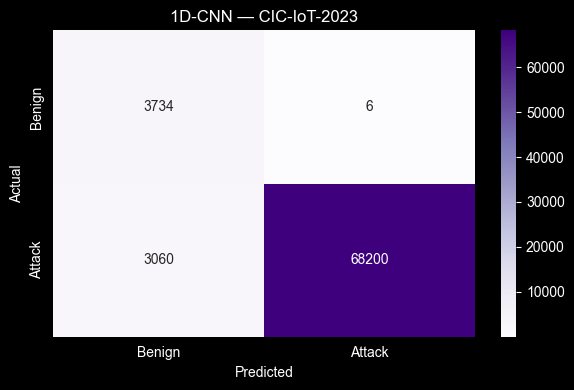


True Negatives:  3734
False Positives: 6
False Negatives: 3060
True Positives:  68200

Model saved.


In [2]:
# ══════════════════════════════════════════════════════════════════════════
# DAY 7 SUMMARY — 1D-CNN on CIC-IoT-2023
# ══════════════════════════════════════════════════════════════════════════
#
# MODEL: 1D Convolutional Neural Network
# Config: 2x Conv1D (64/128 filters), GlobalMaxPool, Dense 64, Dropout 0.3
# Converged at: epoch 26
#
# RESULTS:
#   F1:        0.9780
#   AUC-ROC:   0.9922
#   Precision: 0.9999
#   Recall:    0.9571
#   Accuracy:  0.9591
#
# KEY OBSERVATION:
#   Nearly identical to MLP — same precision pattern (0.9999) with
#   slightly lower recall. CNN did not gain advantage from local feature
#   detection on this tabular data. Classical ML still leads on F1.
#
# LEADERBOARD:
#   1. Random Forest   F1=0.9872  AUC=0.9952
#   2. XGBoost         F1=0.9805  AUC=0.9958
#   3. MLP             F1=0.9786  AUC=0.9929
#   4. 1D-CNN          F1=0.9780  AUC=0.9922
#   5. Log. Regression F1=0.9744  AUC=0.9892
# ══════════════════════════════════════════════════════════════════════════